In [18]:
import geopandas as gpd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from adjustText import adjust_text

In [4]:
tree_loss_grid = gpd.read_file('/mnt/warehouse/shifting_cultivation/111_result/treeloss/display/treeloss_sc_merged_mar13_activities.gpkg')
countries = gpd.read_file('/mnt/warehouse/shifting_cultivation/111_result/output_file/country_class_area_with_coverage_uncertainty_new_over100ha.gpkg')

# Make sure both layers have the same CRS
countries = countries.to_crs(tree_loss_grid.crs)

In [5]:
countries.columns

Index(['Unnamed: 0', 'field_1', 'country', 'class_0_km2', 'class_1_km2',
       'class_2_km2', 'class_3_km2', 'class_4_km2', 'country_area_km2',
       'pred_area_km2', 'coverage_pct', 'prediction_status', 'sc_ci_km2',
       'sc_ci_Mha', 'sc_Mha', 'continent', 'cropland_area', 'geometry'],
      dtype='object')

In [6]:
# 'how="left"' keeps all grids, 'op="intersects"' assigns country based on polygon intersection
grids_with_country = gpd.sjoin(
    tree_loss_grid,
    countries[['country', 'geometry']],  # keep only country name and geometry
    how="left",
    predicate="within"
)

In [7]:
# Count number of grids per country per activity class
country_activity_counts = (
    grids_with_country.groupby(['country', 'activity_class'])
    .size()
    .unstack(fill_value=0)
)

# Add total grids per country
country_activity_counts['Total_grids'] = country_activity_counts.sum(axis=1)

# Compute percentages
country_activity_percent = country_activity_counts.div(country_activity_counts['Total_grids'], axis=0) * 100
country_activity_percent = country_activity_percent.round(1)

print(country_activity_percent)

activity_class   High activity  Hotspots  Low activity  Moderate activity  \
country                                                                     
Angola                    22.4       6.2          10.8               22.1   
Argentina urban            8.0       2.2          11.3               10.9   
Bangladesh                21.1      28.1           3.3               10.4   
Belize                    24.4      14.5          10.8               19.4   
Benin                     11.6       0.5          28.3               30.1   
...                        ...       ...           ...                ...   
Vanuatu                    1.4       0.4          14.5                6.2   
Venezuela                 18.3       2.3          16.2               28.7   
Vietnam                   18.5       8.4          17.3               24.8   
Zambia                    30.8       2.1          11.5               38.7   
Zimbabwe                   6.9       1.6          21.6               15.2   

In [9]:
# Create a new combined column
country_activity_counts['VeryHigh_plus_Hotspot'] = (
    country_activity_counts['Very high activity'] + country_activity_counts['Hotspots']
)

# Optionally compute percentage of combined intensity within country
country_activity_counts['% VeryHigh_plus_Hotspot'] = (
    country_activity_counts['VeryHigh_plus_Hotspot'] / country_activity_counts['Total_grids'] * 100
)

# Sort by the combined percentage
country_activity_counts_sorted = country_activity_counts.sort_values('% VeryHigh_plus_Hotspot', ascending=False)

# Show top countries
print(country_activity_counts_sorted[['VeryHigh_plus_Hotspot', '% VeryHigh_plus_Hotspot']].head(20))

activity_class                VeryHigh_plus_Hotspot  % VeryHigh_plus_Hotspot
country                                                                     
Liberia                                       22392                70.053811
Sierra Leone                                  17766                61.049448
Bangladesh                                     2141                60.123561
Madagascar                                    23234                55.691651
Laos                                          27419                49.597525
Paraguay                                       1262                42.866848
Guatemala                                      3836                39.271089
Democratic Republic of Congo                 127112                39.129083
Honduras                                       3785                32.372562
Cambodia                                       3030                30.930992
Belize                                          517                30.322581

In [10]:
# Merge counts (or percentages) back to country GeoDataFrame
countries_with_activity_counts = countries.merge(
    country_activity_counts,   # or country_activity_counts
    left_on='country',          # column in country GeoDF
    right_index=True,           # because groupby result has country as index
    how='left'
)

# Fill NaNs with 0 if some countries have no grids
countries_with_activity_counts = countries_with_activity_counts.fillna(0)

# Check
print(countries_with_activity_counts.head())

# # Optionally, save as new GeoPackage
# countries_with_activity.to_file(
#     "/path/to/country_activity.gpkg", driver="GPKG"
# )

   Unnamed: 0  field_1          country  class_0_km2  class_1_km2  \
0           0        0           Angola    178943.00     41860.00   
1           1        1  Argentina urban    173134.75      4381.75   
2           3        3       Bangladesh      1623.00      3597.00   
3           4        4           Belize      7618.25      1744.00   
4           5        5            Benin      4468.00      2178.75   

   class_2_km2  class_3_km2  class_4_km2  country_area_km2  pred_area_km2  \
0    632471.25    185261.50     16914.25      1.254507e+06   1.254503e+06   
1    429672.50    179818.50     62839.00      2.785493e+06   8.490366e+05   
2     14614.00     89105.75     25147.50      1.400168e+05   1.400168e+05   
3      3885.00      2673.00      3543.25      2.216461e+04   2.216302e+04   
4     16590.50     49233.75     23190.00      1.160184e+05   1.160184e+05   

   ...                                           geometry High activity  \
0  ...  MULTIPOLYGON (((11.78655 -16.76649, 11.

In [11]:
countries_with_activity_counts["percent_sc"] = 100 * countries_with_activity_counts["class_1_km2"]/countries_with_activity_counts["country_area_km2"]

In [12]:
top10 = countries_with_activity_counts.sort_values(
    'percent_sc', ascending=False
).head(10)

In [13]:
from scipy.stats import spearmanr

rho, pval = spearmanr(
    countries_with_activity_counts['percent_sc'],
    countries_with_activity_counts['% VeryHigh_plus_Hotspot']
)

In [14]:
top20 = countries_with_activity_counts.sort_values(
    'percent_sc', ascending=False
).head(5)

print(top20[['country', 'percent_sc', 'sc_Mha', '% VeryHigh_plus_Hotspot']])

         country  percent_sc    sc_Mha  % VeryHigh_plus_Hotspot
60  Sierra Leone   39.628154  2.895575                61.049448
41       Liberia   33.166441  3.202150                70.053811
39          Laos   23.810160  5.502700                49.597525
32        Guinea   23.322693  5.745700                28.262153
51     Nicaragua   14.223264  1.723300                27.842795


Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


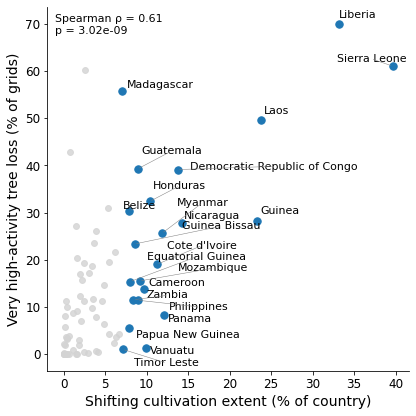

In [19]:
# === General settings ===
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 14
})
color_lorenz = "#1f77b4"
color_box = ["#d9d9d9", "#a6cee3", "#1f78b4", "#b2df8a", "#33a02c", "#e31a1c"]

# === PANEL D: Correlation scatter plot of high-activity tree loss vs SC extent ===
# Spearman correlation using all countries
rho, pval = spearmanr(
    countries_with_activity_counts['percent_sc'],
    countries_with_activity_counts['% VeryHigh_plus_Hotspot']
)

# Identify top 10 countries by SC percentage
top10 = countries_with_activity_counts.sort_values(
    'percent_sc', ascending=False
).head(22)

fig, ax = plt.subplots(figsize=(6,6))

# Scatter plot for all countries
ax.scatter(
    countries_with_activity_counts['percent_sc'],
    countries_with_activity_counts['% VeryHigh_plus_Hotspot'],
    s=35,
    color="lightgray",
    alpha=0.8
)

# Highlight top 10 countries
ax.scatter(
    top10['percent_sc'],
    top10['% VeryHigh_plus_Hotspot'],
    s=55,
    color=color_lorenz
)

# Add labels for top 10 countries
texts = []
for _, row in top10.iterrows():
    texts.append(
        ax.text(
            row['percent_sc'],
            row['% VeryHigh_plus_Hotspot'],
            row['country'],
            fontsize=11
        )
    )

# Adjust text to avoid overlaps
adjust_text(
    texts,
    ax=ax,
    only_move={'points':'y', 'text':'y'},
    arrowprops=dict(arrowstyle='-', color='gray', lw=0.5),
    expand_points=(1.31, 1.2),
    expand_text=(1.2, 1.1)
)

# Axis labels
ax.set_xlabel("Shifting cultivation extent (% of country)")
ax.set_ylabel("Very high-activity tree loss (% of grids)")

# Spearman correlation annotation with scientific notation
ax.text(
    0.02, 0.98,
    f"Spearman ρ = {rho:.2f}\np = {pval:.2e}",
    transform=ax.transAxes,
    fontsize=11,
    verticalalignment='top'
)

# Nature-style axes
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(labelsize=12)

plt.tight_layout()
# plt.savefig(
#     '/mnt/warehouse/shifting_cultivation/111_result/figure/tree_loss/panelD_correlation_sc_hotspot.png',
#     dpi=600
# )
plt.show()

In [20]:
country_activity_counts.columns

Index(['High activity', 'Hotspots', 'Low activity', 'Moderate activity',
       'No tree loss', 'Very high activity', 'Total_grids',
       'VeryHigh_plus_Hotspot', '% VeryHigh_plus_Hotspot'],
      dtype='object', name='activity_class')

In [21]:
continent_counts = (
    countries_with_activity_counts
    .groupby('continent')[[
        'No tree loss',
        'Low activity',
        'Moderate activity',
        'High activity',
        'Very high activity',
        'Hotspots'
    ]]
    .sum()
)

In [22]:
countries_with_activity_counts.columns

Index(['Unnamed: 0', 'field_1', 'country', 'class_0_km2', 'class_1_km2',
       'class_2_km2', 'class_3_km2', 'class_4_km2', 'country_area_km2',
       'pred_area_km2', 'coverage_pct', 'prediction_status', 'sc_ci_km2',
       'sc_ci_Mha', 'sc_Mha', 'continent', 'cropland_area', 'geometry',
       'High activity', 'Hotspots', 'Low activity', 'Moderate activity',
       'No tree loss', 'Very high activity', 'Total_grids',
       'VeryHigh_plus_Hotspot', '% VeryHigh_plus_Hotspot', 'percent_sc'],
      dtype='object')

In [23]:
global_percent = continent_counts / continent_counts.sum() * 100
global_percent = global_percent.round(1)

print(global_percent)

              No tree loss  Low activity  Moderate activity  High activity  \
continent                                                                    
Africa                45.1          46.6               51.3           55.7   
Aisa-Oceania          26.9          26.7               24.8           21.8   
America               28.1          26.7               23.9           22.5   

              Very high activity  Hotspots  
continent                                   
Africa                      60.6      57.1  
Aisa-Oceania                20.7      24.5  
America                     18.7      18.4  


In [24]:
continent_counts['High_intensity'] = (
    continent_counts['Very high activity'] +
    continent_counts['Hotspots']
)

global_share = continent_counts['High_intensity'] / continent_counts['High_intensity'].sum() * 100

In [25]:
print(global_share)

continent
Africa          59.226079
Aisa-Oceania    22.235485
America         18.538437
Name: High_intensity, dtype: float64
